In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

In [32]:
image_paths = sorted(glob.glob("/content/drive/MyDrive/SUIM/TEST/images/*.jpg"))
mask_paths = sorted(glob.glob("/content/drive/MyDrive/SUIM/TEST/masks/*.bmp"))

In [33]:
images = [cv2.imread(p) for p in image_paths]
masks = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in mask_paths]

In [63]:
print(f"Loaded {len(images)} images and {len(masks)} masks")

Loaded 110 images and 110 masks


In [35]:
def compute_metrics(pred, gt):
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)

    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    iou = intersection / union if union != 0 else 0

    dice = (2 * intersection) / (pred_bin.sum() + gt_bin.sum()) if (pred_bin.sum() + gt_bin.sum()) != 0 else 0
    return iou, dice

In [ ]:
gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

In [ ]:
threshold_pred = [cv2.threshold(g, 127, 255, cv2.THRESH_BINARY)[1] for g in gray]

In [ ]:
edges_pred = [cv2.Canny(g, 100, 200) for g in gray]

In [39]:
def kmeans_segmentation(img, gt, K=5):
    Z = img.reshape((-1,3))
    Z = np.float32(Z)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    segmented = labels.reshape((img.shape[0], img.shape[1]))

    clusters = np.unique(segmented)
    overlaps = [np.sum((segmented==c) & (gt>0)) for c in clusters]
    target_cluster = clusters[np.argmax(overlaps)]
    segmented_bin = (segmented == target_cluster).astype(np.uint8) * 255
    return segmented_bin

kmeans_pred = [kmeans_segmentation(img, gt) for img, gt in zip(images, masks)]

In [ ]:
region_pred = []
for g in gray:
    mask = np.zeros((g.shape[0]+2, g.shape[1]+2), np.uint8)
    flood = g.copy()
    seed = (g.shape[1]//2, g.shape[0]//2)
    cv2.floodFill(flood, mask, seedPoint=seed, newVal=255)
    region_mask = (flood > 127).astype(np.uint8) * 255
    region_pred.append(region_mask)


In [41]:
methods = {
    "Thresholding": threshold_pred,
    "Canny": edges_pred,
    "K-means": kmeans_pred,
    "Region Growing": region_pred
}

In [42]:
results = {}
for name, preds in methods.items():
    ious, dices = [], []
    for pred, gt in zip(preds, masks):
        iou, dice = compute_metrics(pred, gt)
        ious.append(iou)
        dices.append(dice)
    results[name] = (np.mean(ious), np.mean(dices))

In [59]:
print("\n=== Average metrics on the TEST set ===")
for name, (iou, dice) in results.items():
    print(f"{name:15} → IoU: {iou:.3f}, Dice: {dice:.3f}")


=== Average metrics on the TEST set ===
Active Contours → IoU: 0.119, Dice: 0.203
Chan–Vese       → IoU: 0.462, Dice: 0.605
Level Sets      → IoU: 0.415, Dice: 0.552


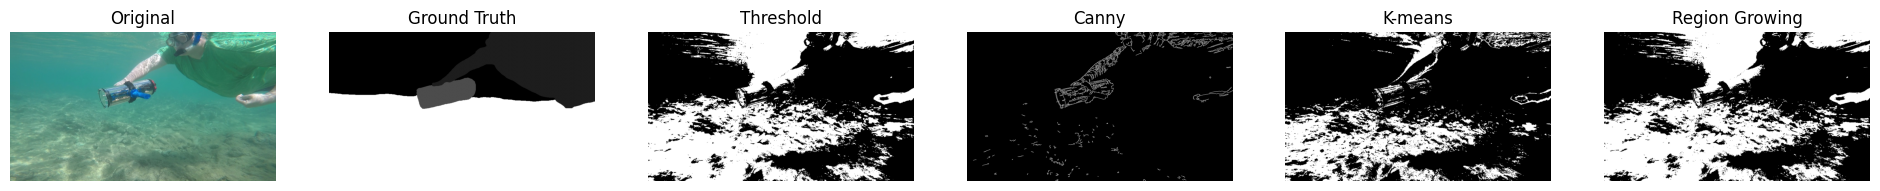

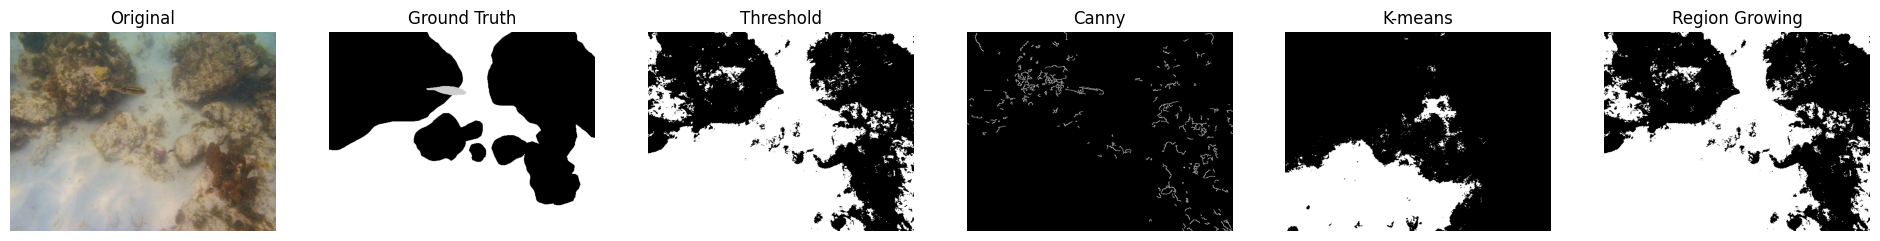

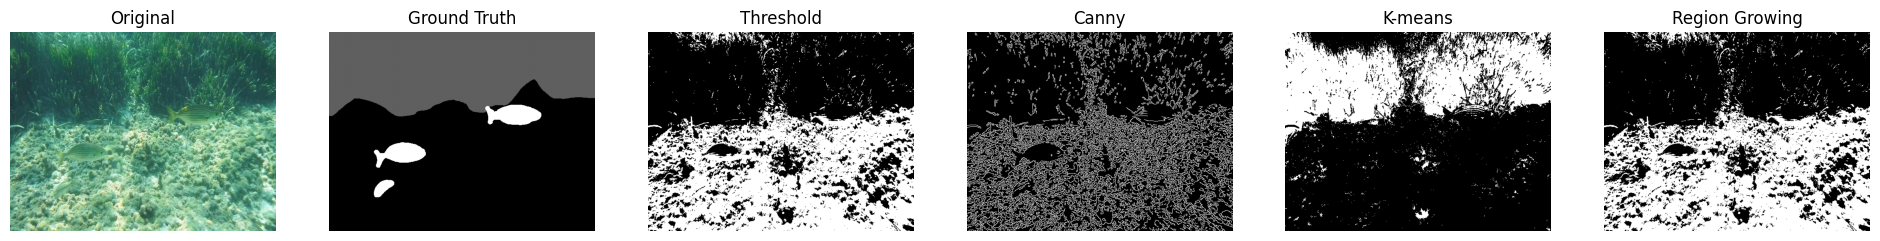

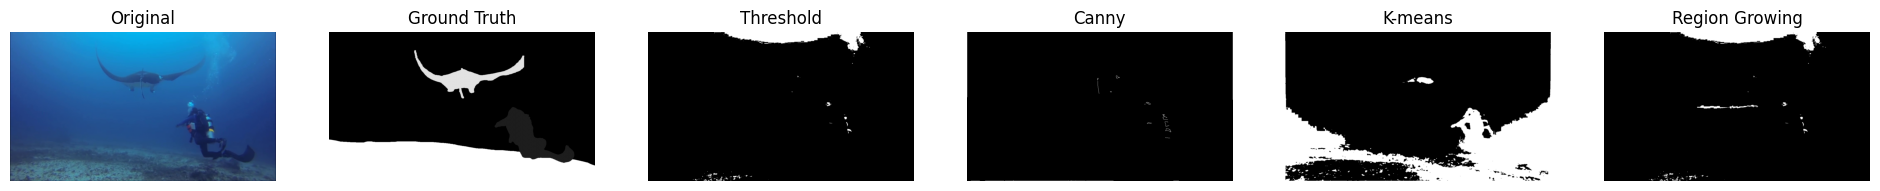

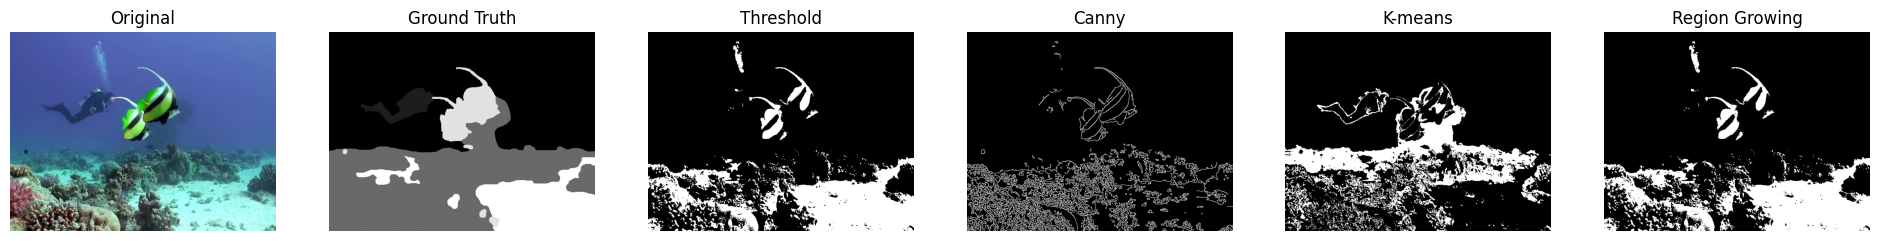

In [44]:
for i in range(5):
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(24,6))
    plt.subplot(1,6,1); plt.imshow(img_rgb); plt.title("Original"); plt.axis("off")
    plt.subplot(1,6,2); plt.imshow(masks[i], cmap="gray"); plt.title("Ground Truth"); plt.axis("off")
    plt.subplot(1,6,3); plt.imshow(threshold_pred[i], cmap="gray"); plt.title("Threshold"); plt.axis("off")
    plt.subplot(1,6,4); plt.imshow(edges_pred[i], cmap="gray"); plt.title("Canny"); plt.axis("off")
    plt.subplot(1,6,5); plt.imshow(kmeans_pred[i], cmap="gray"); plt.title("K-means"); plt.axis("off")
    plt.subplot(1,6,6); plt.imshow(region_pred[i], cmap="gray"); plt.title("Region Growing"); plt.axis("off")
    plt.show()